In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# MEXICO CRIME DATASET ANALYSIS

**Title:** Mexican Crime Statistics: Comprehensive Incident Dataset

**Subtitle:** An Extensive Compilation of Criminal Incidents in Mexico, Sourced from Official Government Data

**Source:** Official Mexican Government Website

**Description:** This dataset is a compilation of criminal incidents reported across Mexico. It includes detailed records of various criminal activities, offering insights into crime patterns and trends in different regions. The dataset is ideal for analysis in criminology, public policy, and data science.

A dataset is provided by Kaggle: https://www.kaggle.com/datasets/elanderos/official-crime-stats-mexico-2015-2023

In [3]:
# Read the dataset
crime_data = pd.read_csv("data/mexico_crime.csv")

In [4]:
crime_data

,year,entity_code,entity,affected_legal_good,type_of_crime,subtype_of_crime,modality,month,count
0,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With firearm,January,3
1,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With sharp weapon,January,1
2,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With another element,January,0
3,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,Not specified,January,2
4,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Manslaughter,With firearm,January,0
...,...,...,...,...,...,...,...,...,...
332411,2022,32,Zacatecas,Other legal interests affected (from common law),Counterfeiting,Forgery,Forgery,December,8
332412,2022,32,Zacatecas,Other legal interests affected (from common law),Environmental crimes,Environmental crimes,Against the environment,December,1
332413,2022,32,Zacatecas,Other legal interests affected (from common law),Crimes committed by public officials,Crimes committed by public servants,Crimes committed by public servants,December,20
332414,2022,32,Zacatecas,Other legal interests affected (from common law),Electoral crimes,Electoral crimes,Electoral crimes,December,0


In [5]:
# See the dataset size
crime_data.shape

(332416, 9)

**SIZE: 
332 416 rows & 9 columns**

### Columns - types and meanings

In [6]:
crime_data.columns

Index(['year', 'entity_code', 'entity', 'affected_legal_good', 'type_of_crime',
       'subtype_of_crime', 'modality', 'month', 'count'],
      dtype='object')

The columns are well-written in a snake_case pattern without spelling errors.

#### Features Types

In [7]:
crime_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332416 entries, 0 to 332415
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   year                 332416 non-null  int64 
 1   entity_code          332416 non-null  int64 
 2   entity               332416 non-null  object
 3   affected_legal_good  332416 non-null  object
 4   type_of_crime        332416 non-null  object
 5   subtype_of_crime     332416 non-null  object
 6   modality             332416 non-null  object
 7   month                332416 non-null  object
 8   count                332416 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 22.8+ MB


I suppose that some features can be converted into the 'category' type.
There are no NaN values.

#### Variable Optimization and Simple Analysis

Now let's look at the variables one by one and see what can be done for optimization

##### Year

Meaning: The year when the crime was reported. This is a numeric field representing the calendar year (e.g., 2015).

In [8]:
crime_data.year.unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [15]:
crime_data.year.value_counts()

year
2015    37632
2016    37632
2017    37632
2018    37632
2019    37632
2020    37632
2021    37632
2022    37632
2023    31360
Name: count, dtype: int64

The years range from 2015 to 2023 but as in the description of the column is written that this is a numeric field. That is why, it is of type integer. However, for the purposes of my analysis I convert it to type 'category'.

In [9]:
crime_data.year = crime_data.year.astype("category")

##### Entity Code

Meaning:  A numeric code representing a specific entity (state or region) within Mexico. Each number corresponds to a unique entity.

In [10]:
crime_data["entity_code"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32])

This means that there are 32 states or regions mentioned. The next variable 'entity' will show if everything is correct in the dataset.

In [11]:
crime_data["entity_code"].dtype

dtype('int64')

The entity code can be a categorical variable because states and regions are unique objects and do not represent quantity as well as their codes.

In [12]:
crime_data["entity_code"] = crime_data["entity_code"].astype("category")

In [14]:
crime_data["entity_code"].value_counts()

entity_code
1     10388
2     10388
3     10388
4     10388
5     10388
6     10388
7     10388
8     10388
9     10388
10    10388
11    10388
12    10388
13    10388
14    10388
15    10388
16    10388
17    10388
18    10388
19    10388
20    10388
21    10388
22    10388
23    10388
24    10388
25    10388
26    10388
27    10388
28    10388
29    10388
30    10388
31    10388
32    10388
Name: count, dtype: int64

Each state/region is mentioned exactly 10 388 times.

##### Entity

Meaning: The name of the Mexican state or region where the crime occurred. This is a textual field (e.g., Aguascalientes).

In [29]:
crime_data.entity.nunique()

32

There are 32 names of states/regions which matches the amount of entity codes.

In [21]:
crime_data.entity.unique()

array(['Aguascalientes', 'Baja California', 'Baja California Sur',
       'Campeche', 'Coahuila de Zaragoza', 'Colima', 'Chiapas',
       'Chihuahua', 'Ciudad de México', 'Durango', 'Guanajuato',
       'Guerrero', 'Hidalgo', 'Jalisco', 'México', 'Michoacán de Ocampo',
       'Morelos', 'Nayarit', 'Nuevo León', 'Oaxaca', 'Puebla',
       'Querétaro', 'Quintana Roo', 'San Luis Potosí', 'Sinaloa',
       'Sonora', 'Tabasco', 'Tamaulipas', 'Tlaxcala',
       'Veracruz de Ignacio de la Llave', 'Yucatán', 'Zacatecas'],
      dtype=object)

In [23]:
# Convert 'entity' to type 'category' as well
crime_data.entity = crime_data.entity.astype("category")

In [24]:
crime_data.entity.value_counts()

entity
Aguascalientes                     10388
Baja California                    10388
Baja California Sur                10388
Campeche                           10388
Chiapas                            10388
Chihuahua                          10388
Ciudad de México                   10388
Coahuila de Zaragoza               10388
Colima                             10388
Durango                            10388
Guanajuato                         10388
Guerrero                           10388
Hidalgo                            10388
Jalisco                            10388
Michoacán de Ocampo                10388
Morelos                            10388
México                             10388
Nayarit                            10388
Nuevo León                         10388
Oaxaca                             10388
Puebla                             10388
Querétaro                          10388
Quintana Roo                       10388
San Luis Potosí                    10388
Sinaloa  

Each state/region is mentioned exactly 10 388 times such as the entity codes so I suppose that there are no simple typing mistakes between entity code and name (for example one unique code for 2 states/regions).

##### Affected Legal Goods

Meaning: A categorical field describing the broad category of the legal good (i.e., personal or societal interest) affected by the crime. Examples include 'Personal freedom' and 'Sexual freedom and security'.

In [31]:
# As it is mentioned that the feature is categorical, I can convert it from object to type 'category'.
crime_data["affected_legal_good"] = crime_data["affected_legal_good"].astype("category") 

# Number of categories
print("Unique categories count: ")
crime_data["affected_legal_good"].nunique()

Unique categories count: 


7

Now let's look at what is most impacted by crime:

In [64]:
value_counts = crime_data["affected_legal_good"].value_counts(normalize = True)
value_counts

affected_legal_good
Heritage or property                                0.428571
Life and bodily integrity                           0.244898
Other legal interests affected (from common law)    0.102041
Personal freedom                                    0.081633
Sexual freedom and security                         0.071429
The family                                          0.040816
Society                                             0.030612
Name: proportion, dtype: float64

And this is heritage or property...

In [28]:
crime_data["affected_legal_good"].describe()

count                   332416
unique                       7
top       Heritage or property
freq                    142464
Name: affected_legal_good, dtype: object

With 142,464 cases, approximately 43% of the affected legal goods are related to heritage or property.
A histogram illustrating the distribution of affected legal goods is provided below.

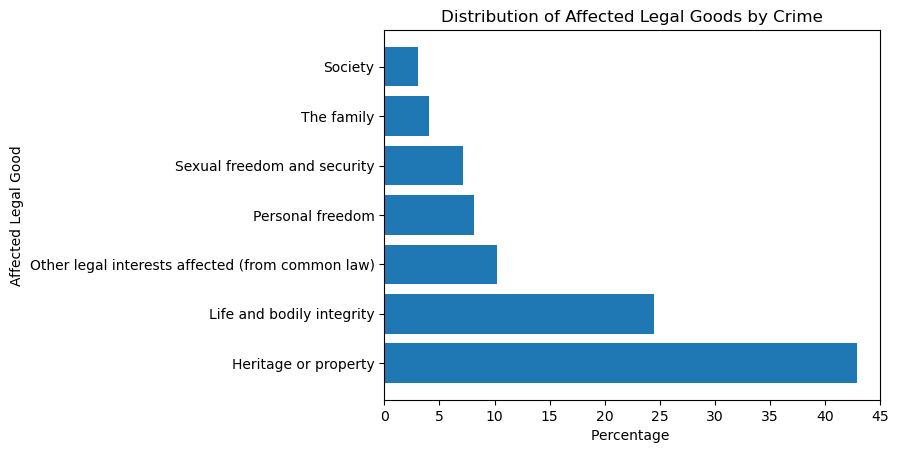

In [81]:
plt.title("Distribution of Affected Legal Goods by Crime")
plt.barh(value_counts.index, value_counts.values * 100)
plt.xlabel("Percentage ")
plt.ylabel("Affected Legal Good")
plt.show()


Bad news is that life and bodily integrity possesses a significant proportion - almost 25%. In terms of Maths, it is not a lot, but in terms of humanity - it is.

##### Type of Crime

Meaning: A categorical field indicating the general type of crime. This field is more specific than 'affected_legal_good' but less specific than 'subtype_of_crime'. Examples include 'Abduction', 'Sexual abuse', and 'Robbery'.

In [82]:
# Since it is mentioned in the description that 'type_of_crime' is a categorial feature, I convert it to such.
crime_data["type_of_crime"] = crime_data["type_of_crime"].astype("category")

In [84]:
# Unique values
crime_data["type_of_crime"].unique()

['Homicide', 'Injuries', 'Feminicide', 'Abortion', 'Other crimes against life and bodily integrity', ..., 'Counterfeiting', 'Environmental crimes', 'Crimes committed by public officials', 'Electoral crimes', 'Other common law crimes']
Length: 39
Categories (39, object): ['Abduction', 'Abortion', 'Aggravated rape', 'Burglary', ..., 'Sexual abuse', 'Sexual harassment', 'Simple rape', 'Threats']

In [86]:
# Crimes are grouped into 39 categories.
# Let's see their distribution...
crime_data["type_of_crime"].value_counts()

type_of_crime
Robbery                                                                122112
Homicide                                                                30528
Injuries                                                                30528
Kidnapping                                                              16960
Feminicide                                                              13568
Sexual harassment                                                        6784
Abduction                                                                3392
Counterfeiting                                                           3392
Corruption of minors                                                     3392
Child trafficking                                                        3392
Burglary                                                                 3392
Aggravated rape                                                          3392
Abortion                                          